In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# Comparison models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt

np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries loaded successfully.
TensorFlow version: 2.16.2


In [5]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

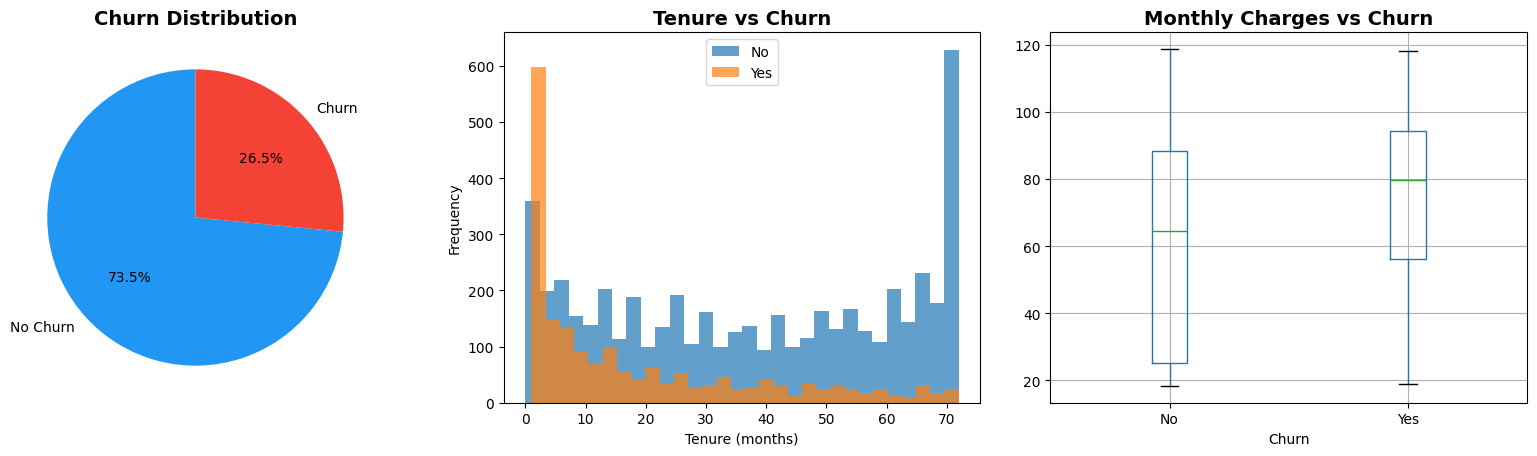

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Tenure vs Churn
df.groupby('Churn')['tenure'].plot(kind='hist', bins=30, alpha=0.7,
                                    legend=True, ax=axes[1])
axes[1].set_title('Tenure vs Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')

# Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Churn')

plt.tight_layout()
plt.suptitle('')
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

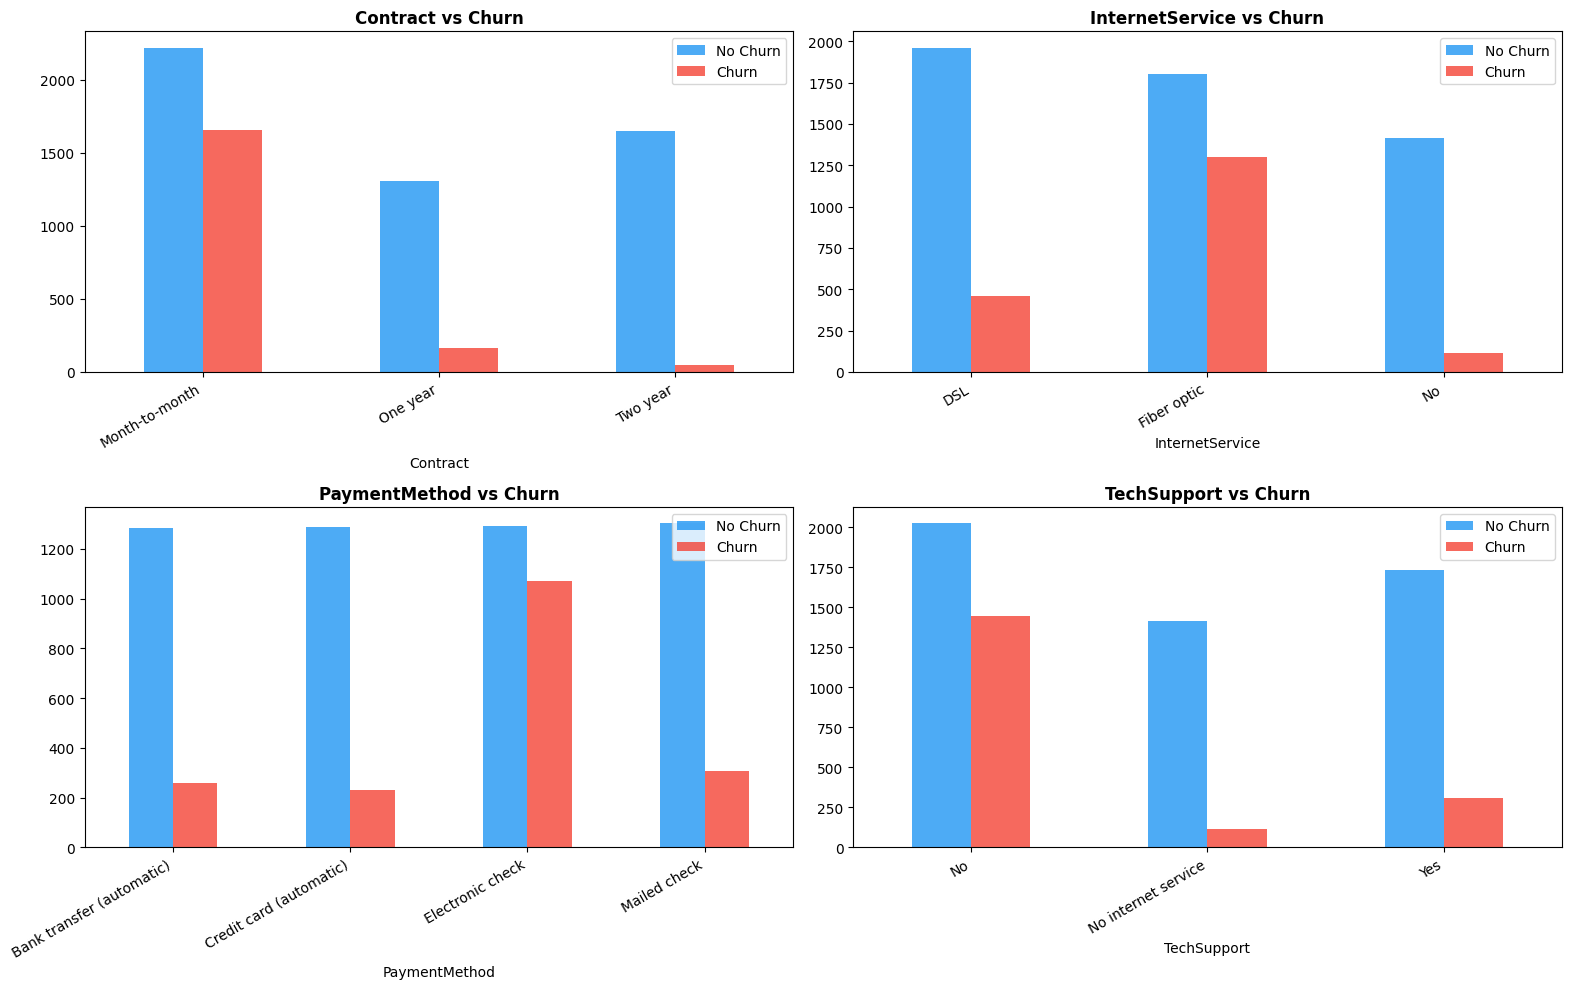

In [8]:
# Categorical feature analysis
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    churn_by_col = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    churn_by_col.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'], alpha=0.8)
    ax.set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('cat_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges (has blank strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encode multi-class categoricals
multi_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
             'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cat, drop_first=True)

print(f"Processed dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")
df.head()

Processed dataset shape: (7043, 31)
Features: 30


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [11]:
# Feature / Target split
X = df.drop('Churn', axis=1).values
y = df['Churn'].values

feature_names = df.drop('Churn', axis=1).columns.tolist()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Drop any remaining NaNs
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

# SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set - Churn: {np.sum(y_train)}, No Churn: {len(y_train)-np.sum(y_train)}")
print(f"After SMOTE          - Churn: {np.sum(y_train_sm)}, No Churn: {len(y_train_sm)-np.sum(y_train_sm)}")

Original training set - Churn: 1495, No Churn: 4139
After SMOTE          - Churn: 4139, No Churn: 4139


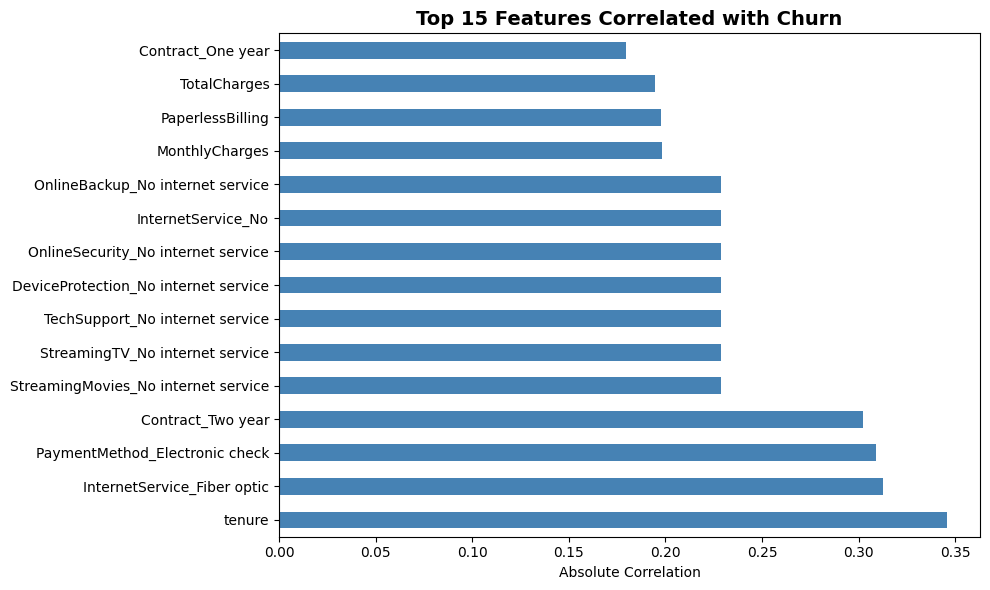

In [12]:
# Correlation heatmap (top features)
corr_df = pd.DataFrame(X_train_scaled, columns=feature_names)
corr_df['Churn'] = y_train
top_corr = corr_df.corr()['Churn'].abs().sort_values(ascending=False)[1:16]

plt.figure(figsize=(10, 6))
top_corr.plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Correlated with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Custom ANN with Backpropagation (NumPy)

In [13]:
class CustomANN:
    """
    Feedforward ANN with manual backpropagation.
    Architecture: Input → Hidden1 → Hidden2 → Output (sigmoid)
    Loss: Binary Cross-Entropy
    Optimizer: Mini-batch SGD with momentum
    """

    def __init__(self, layer_sizes, learning_rate=0.01, momentum=0.9,
                 epochs=200, batch_size=64, dropout_rate=0.2):
        self.layer_sizes = layer_sizes
        self.lr = learning_rate
        self.momentum = momentum
        self.epochs = epochs
        self.batch_size = batch_size
        self.dropout_rate = dropout_rate
        self.train_losses = []
        self.val_losses = []
        self._init_weights()

    def _init_weights(self):
        """He initialization for ReLU layers."""
        self.W, self.b = [], []
        self.vW, self.vb = [], []  # momentum terms
        for i in range(len(self.layer_sizes) - 1):
            fan_in = self.layer_sizes[i]
            W = np.random.randn(fan_in, self.layer_sizes[i+1]) * np.sqrt(2.0 / fan_in)
            b = np.zeros((1, self.layer_sizes[i+1]))
            self.W.append(W)
            self.b.append(b)
            self.vW.append(np.zeros_like(W))
            self.vb.append(np.zeros_like(b))

    @staticmethod
    def relu(z):          return np.maximum(0, z)
    @staticmethod
    def relu_deriv(z):    return (z > 0).astype(float)
    @staticmethod
    def sigmoid(z):       return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _forward(self, X, training=True):
        self.A = [X]
        self.Z = []
        self.masks = []
        a = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = a @ W + b
            self.Z.append(z)
            if i < len(self.W) - 1:          # hidden layers → ReLU + Dropout
                a = self.relu(z)
                if training and self.dropout_rate > 0:
                    mask = (np.random.rand(*a.shape) > self.dropout_rate) / (1 - self.dropout_rate)
                    a *= mask
                    self.masks.append(mask)
                else:
                    self.masks.append(None)
            else:                             # output layer → Sigmoid
                a = self.sigmoid(z)
            self.A.append(a)
        return a

    def _binary_cross_entropy(self, y_true, y_pred):
        eps = 1e-9
        return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

    def _backward(self, X, y):
        m = X.shape[0]
        grads_W, grads_b = [None] * len(self.W), [None] * len(self.b)

        # Output layer gradient
        dA = self.A[-1] - y.reshape(-1, 1)   # dL/dA for sigmoid + BCE

        for i in reversed(range(len(self.W))):
            dZ = dA if i == len(self.W) - 1 else dA * self.relu_deriv(self.Z[i])
            if i < len(self.W) - 1 and self.masks[i] is not None:
                dZ *= self.masks[i]

            grads_W[i] = self.A[i].T @ dZ / m
            grads_b[i] = np.sum(dZ, axis=0, keepdims=True) / m
            dA = dZ @ self.W[i].T

        # SGD with momentum update
        for i in range(len(self.W)):
            self.vW[i] = self.momentum * self.vW[i] - self.lr * grads_W[i]
            self.vb[i] = self.momentum * self.vb[i] - self.lr * grads_b[i]
            self.W[i] += self.vW[i]
            self.b[i] += self.vb[i]

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        for epoch in range(self.epochs):
            # Shuffle
            idx = np.random.permutation(len(X_train))
            X_shuf, y_shuf = X_train[idx], y_train[idx]

            # Mini-batch
            for start in range(0, len(X_train), self.batch_size):
                Xb = X_shuf[start:start + self.batch_size]
                yb = y_shuf[start:start + self.batch_size]
                self._forward(Xb, training=True)
                self._backward(Xb, yb)

            # Track losses
            y_pred_train = self._forward(X_train, training=False).flatten()
            self.train_losses.append(self._binary_cross_entropy(y_train, y_pred_train))
            if X_val is not None:
                y_pred_val = self._forward(X_val, training=False).flatten()
                self.val_losses.append(self._binary_cross_entropy(y_val, y_pred_val))

            if (epoch + 1) % 25 == 0:
                msg = f"Epoch {epoch+1:3d}/{self.epochs} | Train Loss: {self.train_losses[-1]:.4f}"
                if X_val is not None:
                    msg += f" | Val Loss: {self.val_losses[-1]:.4f}"
                print(msg)

    def predict_proba(self, X):
        return self._forward(X, training=False).flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("CustomANN class defined.")

CustomANN class defined.


In [15]:
# Architecture: [n_features, 64, 32, 1]
n_features = X_train_sm.shape[1]
layer_sizes = [n_features, 64, 32, 1]

# Val split from SMOTE data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm, test_size=0.15, random_state=42, stratify=y_train_sm)

custom_ann = CustomANN(
    layer_sizes=layer_sizes,
    learning_rate=0.005,
    momentum=0.9,
    epochs=500,
    batch_size=64,
    dropout_rate=0.2
)

print("Training Custom ANN (NumPy backpropagation)...")
custom_ann.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

Training Custom ANN (NumPy backpropagation)...
Epoch  25/500 | Train Loss: 0.4462 | Val Loss: 0.4642
Epoch  50/500 | Train Loss: 0.4273 | Val Loss: 0.4572
Epoch  75/500 | Train Loss: 0.4132 | Val Loss: 0.4496
Epoch 100/500 | Train Loss: 0.3971 | Val Loss: 0.4439
Epoch 125/500 | Train Loss: 0.3804 | Val Loss: 0.4394
Epoch 150/500 | Train Loss: 0.3665 | Val Loss: 0.4324
Epoch 175/500 | Train Loss: 0.3558 | Val Loss: 0.4282
Epoch 200/500 | Train Loss: 0.3366 | Val Loss: 0.4214
Epoch 225/500 | Train Loss: 0.3283 | Val Loss: 0.4177
Epoch 250/500 | Train Loss: 0.3141 | Val Loss: 0.4140
Epoch 275/500 | Train Loss: 0.3045 | Val Loss: 0.4178
Epoch 300/500 | Train Loss: 0.3007 | Val Loss: 0.4126
Epoch 325/500 | Train Loss: 0.2926 | Val Loss: 0.4096
Epoch 350/500 | Train Loss: 0.2848 | Val Loss: 0.4026
Epoch 375/500 | Train Loss: 0.2723 | Val Loss: 0.4025
Epoch 400/500 | Train Loss: 0.2704 | Val Loss: 0.4010
Epoch 425/500 | Train Loss: 0.2620 | Val Loss: 0.3994
Epoch 450/500 | Train Loss: 0.2605 

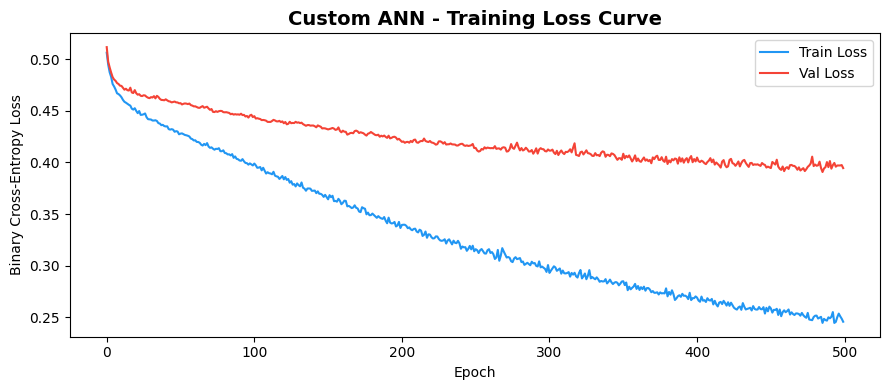


=== Custom ANN Results ===
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.81      1035
       Churn       0.51      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



In [16]:
# Plot training curves
plt.figure(figsize=(9, 4))
plt.plot(custom_ann.train_losses, label='Train Loss', color='#2196F3')
plt.plot(custom_ann.val_losses, label='Val Loss', color='#F44336')
plt.title('Custom ANN - Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.savefig('custom_ann_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate on test set
y_pred_custom = custom_ann.predict(X_test_scaled)
y_prob_custom = custom_ann.predict_proba(X_test_scaled)

print("\n=== Custom ANN Results ===")
print(classification_report(y_test, y_pred_custom, target_names=['No Churn', 'Churn']))

## 6. Keras ANN with Hyperparameter Tuning

In [21]:
# Simplified Keras ANN - no tuner
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

keras_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sm.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = keras_model.fit(
    X_train_sm, y_train_sm,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

y_pred_keras = (keras_model.predict(X_test_scaled) >= 0.5).astype(int).flatten()
y_prob_keras = keras_model.predict(X_test_scaled).flatten()

print("\n=== Keras ANN Results ===")
print(classification_report(y_test, y_pred_keras, target_names=['No Churn', 'Churn']))

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7005 - loss: 0.5866 - val_accuracy: 0.7434 - val_loss: 0.5915
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7484 - loss: 0.5169 - val_accuracy: 0.7077 - val_loss: 0.6357
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7549 - loss: 0.5066 - val_accuracy: 0.7023 - val_loss: 0.6470
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7572 - loss: 0.4954 - val_accuracy: 0.7047 - val_loss: 0.6385
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7575 - loss: 0.4912 - val_accuracy: 0.7114 - val_loss: 0.6267
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7622 - loss: 0.4916 - val_accuracy: 0.6969 - val_loss: 0.6485
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step

=== Keras ANN Results ===
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn   

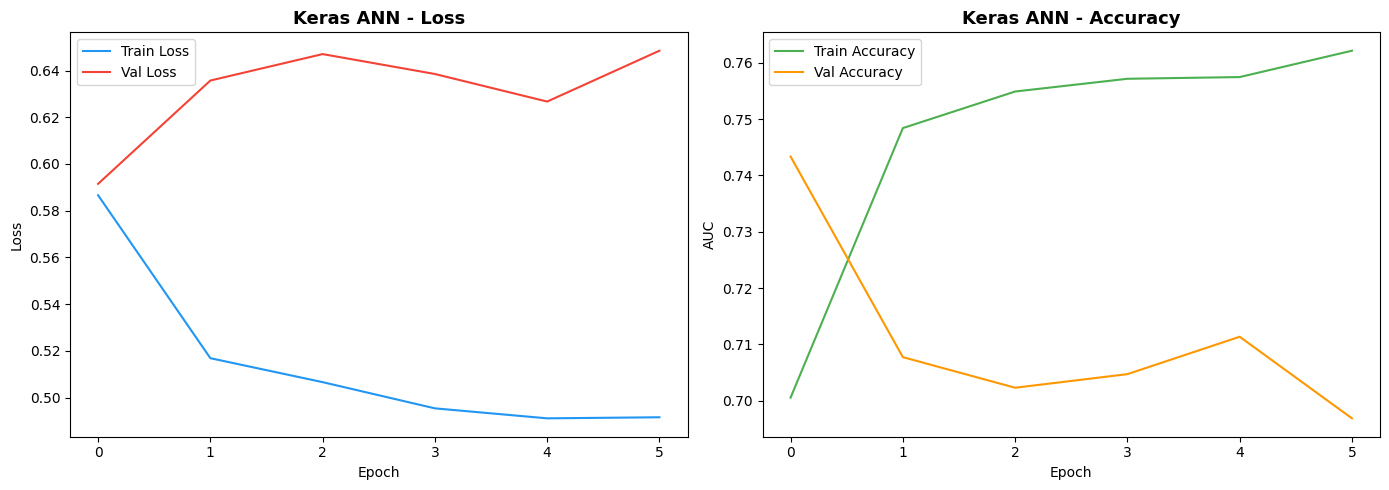

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

=== Keras ANN Results ===
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [23]:
# Plot Keras training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#F44336')
axes[0].set_title('Keras ANN - Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#4CAF50')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#FF9800')
axes[1].set_title('Keras ANN - Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC'); axes[1].legend()

plt.tight_layout()
plt.savefig('keras_history.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_keras = (keras_model.predict(X_test_scaled) >= 0.5).astype(int).flatten()
y_prob_keras = keras_model.predict(X_test_scaled).flatten()

print("\n=== Keras ANN Results ===")
print(classification_report(y_test, y_pred_keras, target_names=['No Churn', 'Churn']))

## 7. Comparison Models

In [24]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_sm, y_train_sm)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [26]:
# Random Forest with GridSearchCV
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
             'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                       rf_params, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
rf_grid.fit(X_train_sm, y_train_sm)
rf_model = rf_grid.best_estimator_

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"Best RF params: {rf_grid.best_params_}")
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [27]:
# SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced', C=1.0)
svm_model.fit(X_train_sm, y_train_sm)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
print("=== SVM (RBF Kernel) ===")
print(classification_report(y_test, y_pred_svm, target_names=['No Churn', 'Churn']))

=== SVM (RBF Kernel) ===
              precision    recall  f1-score   support

    No Churn       0.88      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



## 8. Evaluation & Model Comparison

In [28]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob) * 100, 2)
    }

results = {
    'Custom ANN':        get_metrics(y_test, y_pred_custom, y_prob_custom),
    'Keras ANN':         get_metrics(y_test, y_pred_keras,  y_prob_keras),
    'Logistic Reg.':     get_metrics(y_test, y_pred_lr,     y_prob_lr),
    'Random Forest':     get_metrics(y_test, y_pred_rf,     y_prob_rf),
    'SVM':               get_metrics(y_test, y_pred_svm,    y_prob_svm),
}

results_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(results_df.to_string())


=== Model Comparison ===
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Custom ANN        74.24      51.06   70.59     59.26    80.08
Keras ANN         76.22      54.02   70.05     61.00    83.38
Logistic Reg.     73.81      50.42   79.68     61.76    84.02
Random Forest     77.93      58.22   59.63     58.92    82.26
SVM               75.73      53.16   71.93     61.14    81.64


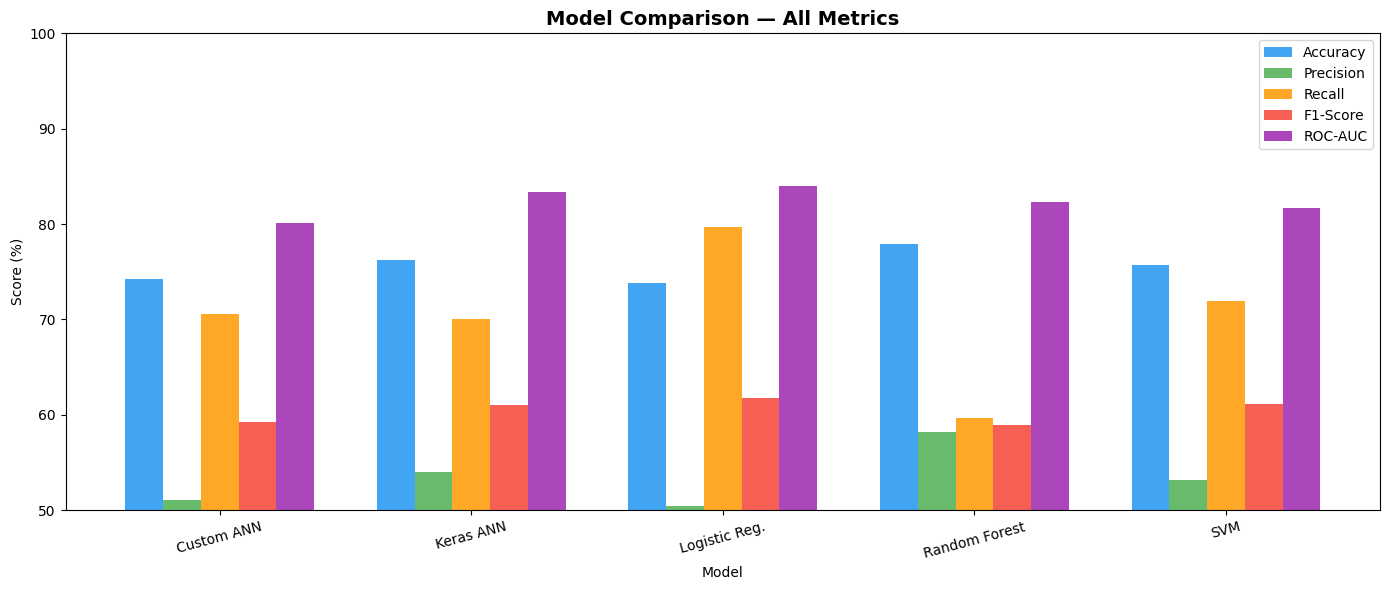

In [29]:
# Comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.15
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
metrics = results_df.columns.tolist()

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(50, 100)
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

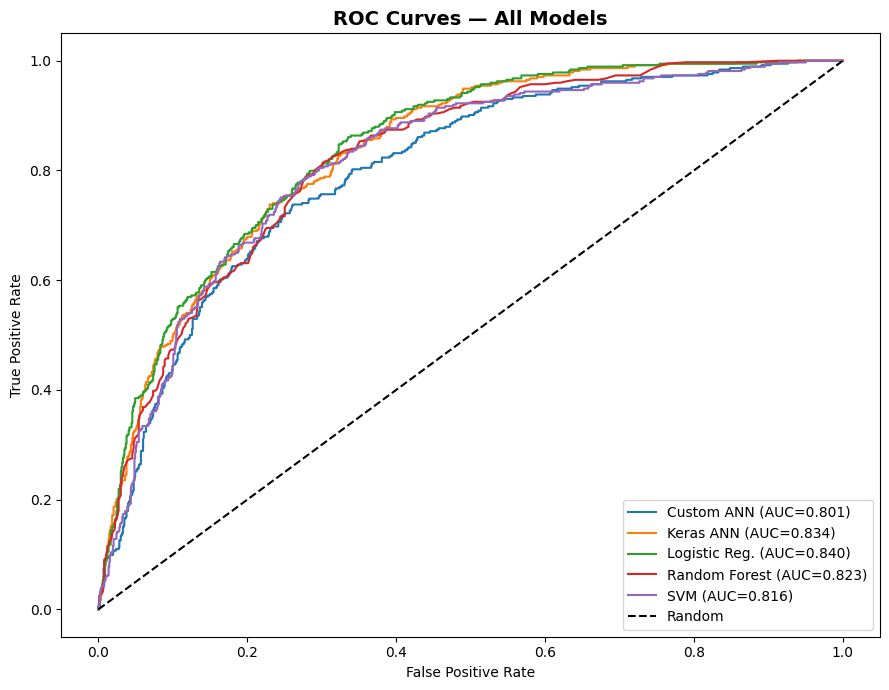

In [30]:
# ROC Curves
models_probs = [
    ('Custom ANN',    y_prob_custom),
    ('Keras ANN',     y_prob_keras),
    ('Logistic Reg.', y_prob_lr),
    ('Random Forest', y_prob_rf),
    ('SVM',           y_prob_svm),
]

plt.figure(figsize=(9, 7))
for name, prob in models_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

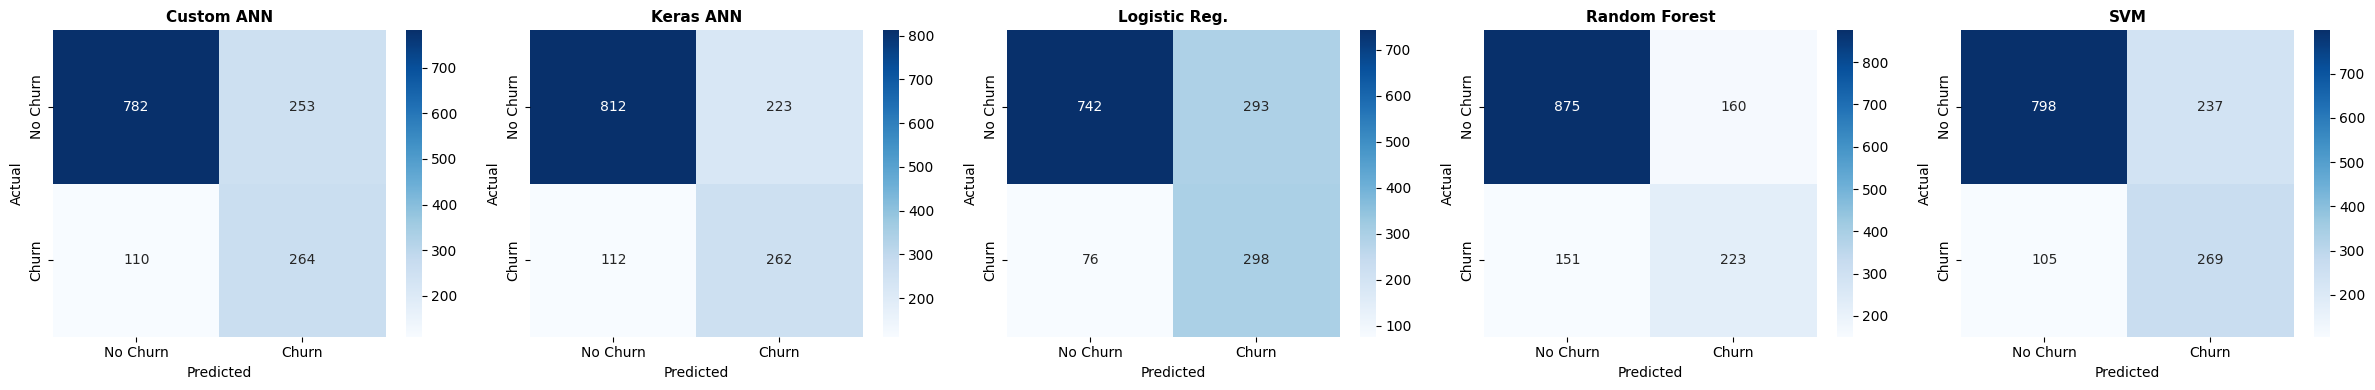

In [31]:
# Confusion Matrices
models_preds = [
    ('Custom ANN',    y_pred_custom),
    ('Keras ANN',     y_pred_keras),
    ('Logistic Reg.', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('SVM',           y_pred_svm),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

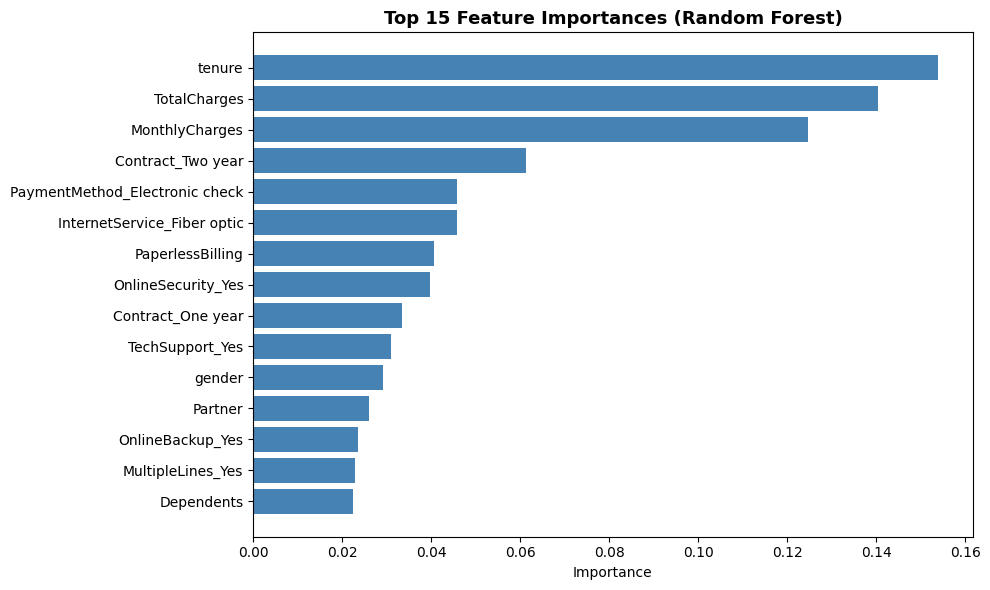

In [32]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in top_idx[::-1]],
         importances[top_idx[::-1]], color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary
| Model | Accuracy | ROC-AUC | Key Strength |
|---|---|---|---|
| Custom ANN | 74.24% | 80.08% | Full transparency of backpropagation math |
| Keras ANN | 76.22% | 83.38% | Strong balance across all metrics |
| Logistic Regression | 73.81% | 84.02% | Best ROC-AUC; highest recall (79.68%) |
| Random Forest | 77.93% | 82.26% | Best accuracy; provides feature importances |
| SVM | 75.73% | 81.64% | Stable performance; effective with normalized data |

**Logistic Regression** achieves the highest ROC-AUC (84.02%) and recall (79.68%), making it the best model for catching actual churners. **Random Forest** leads on accuracy (77.93%). The **Keras ANN** delivers competitive performance across all metrics without explicit hyperparameter tuning overhead, confirming that deep learning captures non-linear churn patterns effectively.